## Clustering

# ML - Aprendizaje No Supervisado

En la mayoría de los casos, nuestros datos no vienen con etiquetas. Etiquetarlos manualmente puede ser costoso y llevar mucho tiempo. Por eso existen técnicas de aprendizaje no supervisado (*Unsupervised Learning*), que nos permiten analizar y descubrir patrones en los datos sin necesidad de etiquetas previas.

El *Clustering* es una técnica popular de aprendizaje no supervisado que agrupa datos similares en conjuntos llamados *clusters*. Esto ayuda a descubrir patrones y segmentar información, siendo útil en áreas como la segmentación de clientes, análisis de datos, reducción de dimensiones, detección de anomalías y motores de búsqueda.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

n_centers = random.randint(1, 20)

blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)

from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)


Se generaron 19
Coordenadas de los centroides:
[[-3.9414993  -9.81251015]
 [-2.77066275  2.92594541]
 [ 2.89619117 -5.22629198]
 [ 5.14448866  7.23550364]
 [-6.57260747 -7.71219833]
 [ 9.57859494 -7.50312906]
 [ 2.87648757  3.03123879]
 [-9.04859707  7.54663359]
 [-1.29473448  0.52762433]
 [-6.53133377  1.20057395]
 [-1.89877926  7.60616342]
 [ 2.65089952  5.23465253]
 [ 9.54274812  1.94682085]
 [-1.93251313 -6.36273369]
 [-6.89201065 -3.36452752]
 [-5.05128165  9.43078007]
 [-8.61196704 -0.03899792]
 [ 9.59948647  8.05564341]
 [-6.96908526  7.02050883]]


In [ ]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

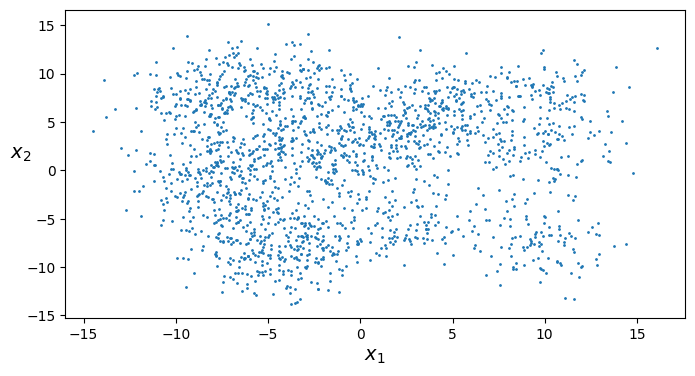

In [ ]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.  

In [ ]:
from sklearn.cluster import KMeans
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([14, 18, 17, ..., 10, 12, 14], dtype=int32)

In [ ]:
kmeans.cluster_centers_

array([[  3.47326356,   3.17467083],
       [ -9.31797925,  -1.11936109],
       [ -2.11612858,  -7.13355705],
       [ -2.5641844 ,   9.85431317],
       [  9.59819408,   4.25503126],
       [  9.79362477,  -6.02048219],
       [ -4.44918599,   6.45601686],
       [ -0.21114963,   4.68994684],
       [ 10.20736034,   8.61936573],
       [ -6.53891195,  -5.0795549 ],
       [  2.9834216 ,  -5.54888661],
       [ -5.25020853, -10.19716116],
       [ -7.50444645,  10.11033943],
       [  9.69053963,  -9.64728108],
       [ -1.37434158,   0.05251537],
       [  4.43635185,   7.73296938],
       [ -5.95934221,   1.54189684],
       [ -9.13561028,   6.14719996],
       [  9.58104328,   0.35730953]])

In [ ]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([14,  0,  7, 14], dtype=int32)

In [ ]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

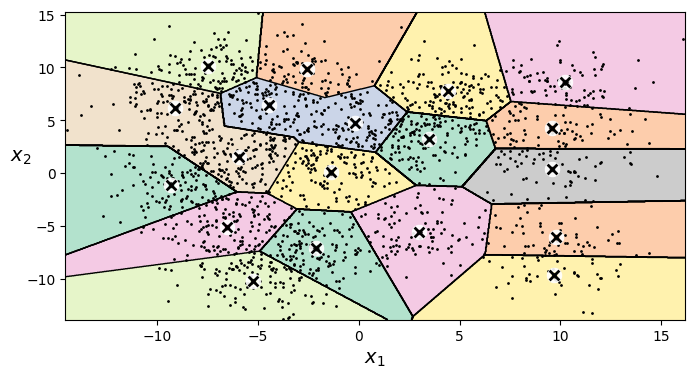

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()


En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [ ]:
kmeans.transform(X_new)

array([[ 3.66652578,  9.82624806,  9.37549277,  8.26228037,  9.85953831,
        12.65872113,  6.29693118,  2.6982213 , 12.1657802 ,  9.63729563,
         8.11704956, 13.27913514, 11.04962996, 15.15142617,  2.38359207,
         7.24901066,  5.9769238 , 10.03287808,  9.72084473],
       [ 1.26642408, 12.70681024, 10.4688412 ,  9.62550691,  6.97289976,
        10.5110167 ,  8.68023377,  4.18894927,  9.78580839, 11.87901253,
         7.54890482, 14.72537542, 13.27105878, 13.43214343,  4.78827324,
         5.91016451,  8.97104628, 12.8246756 ,  6.7829612 ],
       [ 6.47561974,  7.54228066, 10.17203064,  6.86815435, 12.66055282,
        15.65394307,  3.74755822,  3.26092114, 14.35310553,  8.82060684,
        10.43478779, 13.38762493,  8.4170639 , 17.91657096,  3.36607055,
         8.81477895,  3.2990561 ,  6.89569294, 12.85560045],
       [ 6.50832712,  7.2812524 ,  9.67401934,  7.36721504, 12.71985176,
        15.37125406,  4.21309974,  3.54592069, 14.55613287,  8.36501944,
        10.029

Este algoritmo comienza eligiendo algunos puntos al azar como centroides. Luego, en cada paso, agrupa las muestras según el centroide más cercano y actualiza la posición de cada centroide calculando el promedio de los puntos que le han tocado. Así, poco a poco, los grupos y sus centros se van ajustando hasta que todo queda bien repartido.



In [ ]:
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="full", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="lloyd", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=5,
                    #  algorithm="elkan", max_iter=1, random_state=1)
# Configuración del modelo K-Means con inicialización inteligente
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=2, random_state=1)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=3, random_state=1)
# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=3, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
print(kmeans_iter1)
kmeans_iter2.fit(X)
print(kmeans_iter2)
kmeans_iter3.fit(X)
print(kmeans_iter3)

KMeans(algorithm='elkan', max_iter=3, n_clusters=19, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=19, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=19, n_init=1, random_state=5)


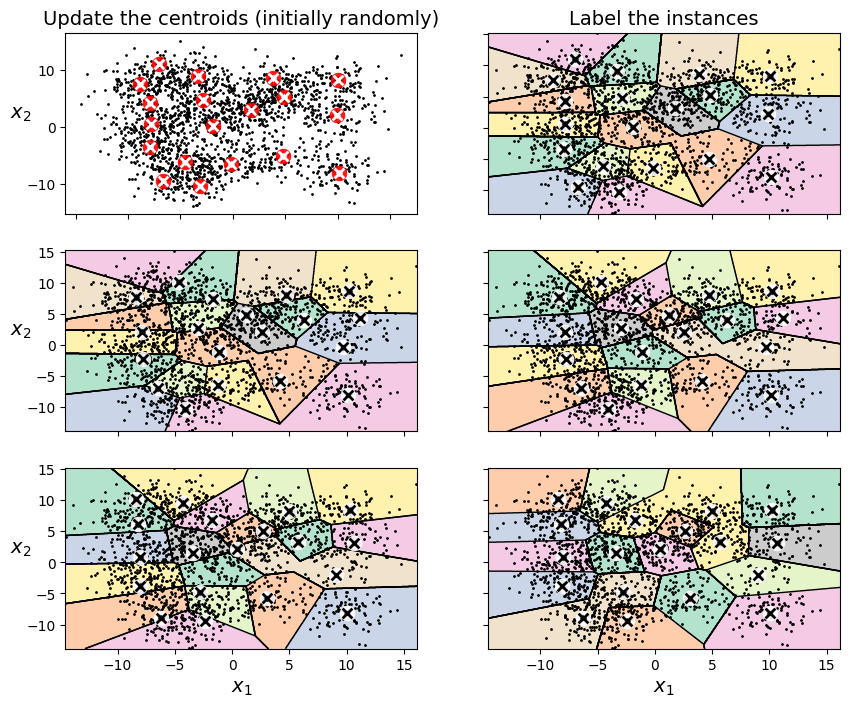

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [ ]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

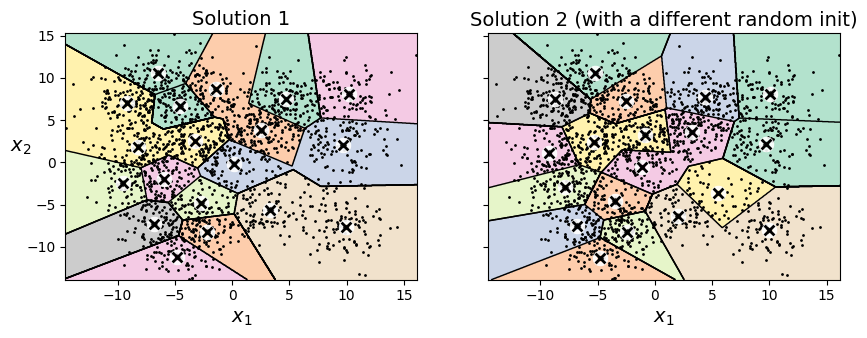

In [ ]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Para evitar que la inicialización afecte demasiado al resultado, podemos probar varias veces con diferentes valores iniciales y elegir la mejor opción, o bien utilizar la inicialización inteligente que viene por defecto en *Scikit-Learn*.

In [ ]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)
print(kmeans_rnd_10_inits)

KMeans(algorithm='elkan', init='random', n_clusters=19, n_init=10,
       random_state=11)


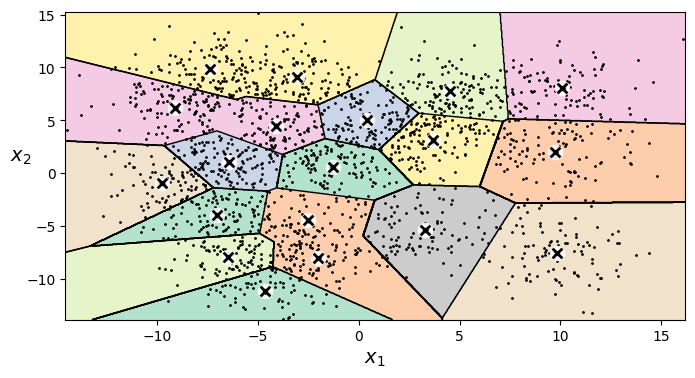

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

Existen varias formas de mejorar el algoritmo *K-Means*. Por ejemplo, hay versiones más rápidas (como la que usa *Scikit-Learn* por defecto, que optimiza el cálculo de distancias) y también está el *mini-batch K-Means*, ideal cuando el conjunto de datos es tan grande que no cabe en memoria. A continuación veremos cómo funciona este último usando el dataset MNIST, empleando el objeto [MiniBatchKMeans]

In [ ]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [ ]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [ ]:
best_kmeans.score(X)

-33564.30604957171

El algoritmo de mini-batch K-Means funciona mucho más rápido que el K-Means tradicional, aunque normalmente sacrifica algo de precisión a cambio de esa velocidad.



### Encontrando el número óptimo de grupos

El número de clusters es un parámetro clave que debemos elegir al usar estos modelos. Cuando no tenemos etiquetas, no sabemos cuál es el valor ideal, así que probamos varios y usamos métricas para decidir. Una de las más útiles es el silhouette score, que mide qué tan bien está cada muestra dentro de su grupo: valores cercanos a 1 indican que la muestra está bien agrupada, cerca de 0 que está en el límite entre grupos, y negativos que probablemente está en el grupo equivocado.



In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.34047532955229787)

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

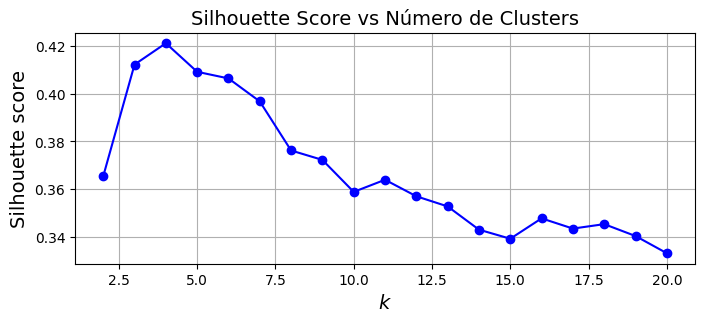

In [ ]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = 20
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

### ELBOW METHOD

Calcula la inercia para distintos valores de k

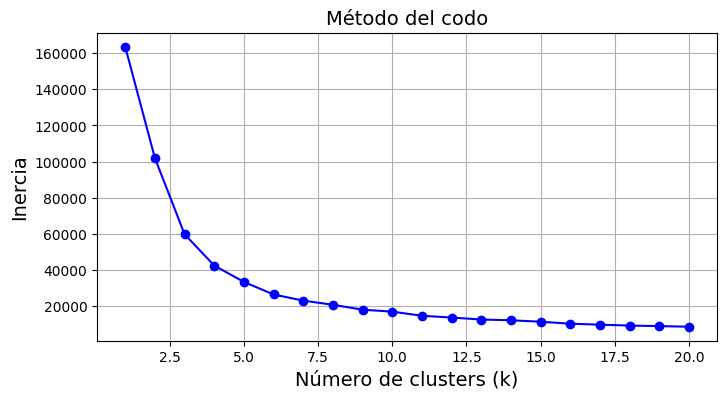

In [ ]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()


También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

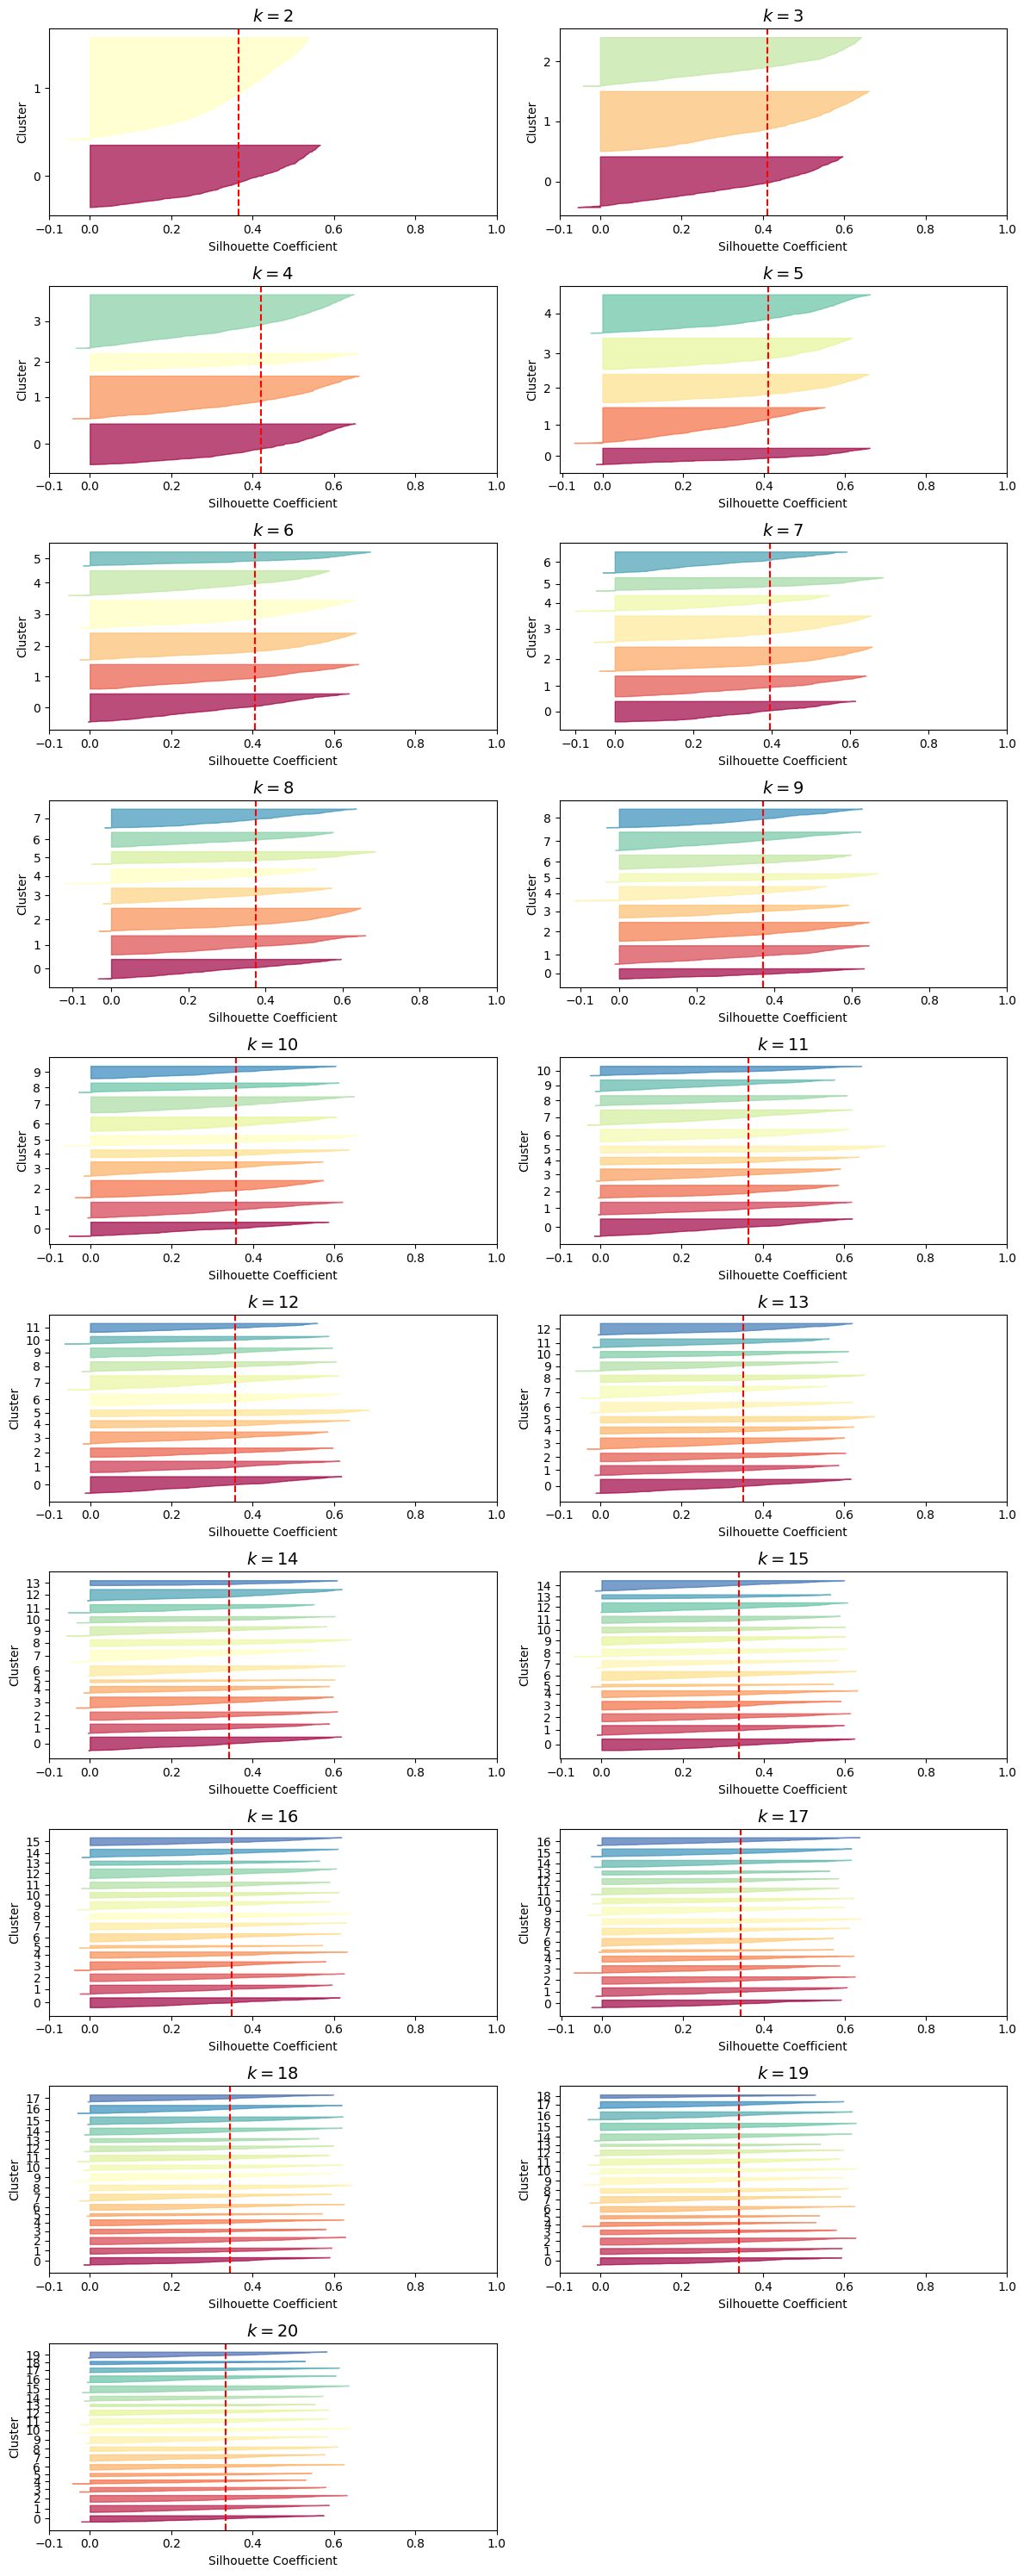

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()


### K-Means para aprendizaje semi-supervisado.

El aprendizaje semi-supervisado, también conocido como Semi-supervised Learning, reúne técnicas que nos ayudan a entrenar modelos cuando solo tenemos una parte de los datos etiquetados. En esta sección veremos, de forma práctica y sencilla, cómo aplicar este enfoque usando el dataset de flores (14 clases) y el algoritmo K-Means. Para comenzar, cargamos el dataset y prepararemos los datos.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
from pathlib import Path

ZIP_PATH   = Path("/content/drive/MyDrive/SIS420/flores.zip")
DEST_PATH  = Path("/content/flores")

print("Descomprimiendo... (puede tardar 1-2 minutos)")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DEST_PATH)

print("Listo. Contenido:")
for item in sorted(DEST_PATH.iterdir()):
    print(" ", item.name)

Descomprimiendo... (puede tardar 1-2 minutos)
Listo. Contenido:
  classname.txt
  train
  train.csv
  val
  val.csv


In [ ]:
# Ajustar BASE_PATH según lo que imprimió la celda anterior
# Puede ser /content/flores o /content/flores/Flores dependiendo de cómo zipeaste
BASE_PATH = Path("/content/flores")

# Si ves una carpeta adentro, descomentá esta línea:
# BASE_PATH = Path("/content/flores/Flores")

print("¿Existe train/?", (BASE_PATH / "train").exists())
print("\nClases en train/:")
for item in sorted((BASE_PATH / "train").iterdir()):
    if item.is_dir():
        n = len(list(item.iterdir()))
        print(f"  {item.name:20s}: {n} imágenes")

¿Existe train/? True

Clases en train/:
  astilbe             : 726 imágenes
  bellflower          : 872 imágenes
  black_eyed_susan    : 986 imágenes
  calendula           : 1011 imágenes
  california_poppy    : 1021 imágenes
  carnation           : 924 imágenes
  common_daisy        : 978 imágenes
  coreopsis           : 1035 imágenes
  dandelion           : 1038 imágenes
  iris                : 1041 imágenes
  rose                : 986 imágenes
  sunflower           : 1013 imágenes
  tulip               : 1034 imágenes
  water_lily          : 977 imágenes


In [ ]:
import numpy as np
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

IMG_SIZE   = (128, 128)
EXTENSIONS = {".jpg", ".jpeg", ".png"}
BASE_PATH  = Path("/content/flores")

In [ ]:
def cargar_split(split: str):
    imagenes, etiquetas = [], []

    carpeta_split = BASE_PATH / split
    clases = sorted([c for c in carpeta_split.iterdir() if c.is_dir()])
    clase_a_idx = {c.name: i for i, c in enumerate(clases)}

    print(f"\n  Cargando '{split}' — {len(clases)} clases encontradas")

    for carpeta in clases:
        rutas = [r for r in carpeta.iterdir() if r.suffix.lower() in EXTENSIONS]
        for ruta in rutas:
            try:
                img = Image.open(ruta).convert("RGB")
                img = img.resize(IMG_SIZE, Image.LANCZOS)
                imagenes.append(np.array(img))
                etiquetas.append(clase_a_idx[carpeta.name])
            except Exception as e:
                print(f"    Saltando {ruta.name}: {e}")

        print(f"    {carpeta.name:20s}: {len(rutas)} imgs")

    X = np.stack(imagenes).astype(np.float32) / 255.0
    y = np.array(etiquetas, dtype=np.int64)
    return X, y, [c.name for c in clases]

In [ ]:
print("Cargando train...")
X_train_full, y_train_full, nombres_clase = cargar_split("train")

X_test, y_test, _ = cargar_split("val")

print(f"\nClases ({len(nombres_clase)}): {nombres_clase}")
print(f"X_train_full : {X_train_full.shape}  —  {X_train_full.nbytes / 1e9:.2f} GB")
print(f"X_test       : {X_test.shape}        —  {X_test.nbytes / 1e9:.2f} GB")
print(f"y_train_full : {y_train_full.shape}")
print(f"y_test       : {y_test.shape}")

Cargando train...

  Cargando 'train' — 14 clases encontradas
    astilbe             : 726 imgs
    bellflower          : 872 imgs
    black_eyed_susan    : 986 imgs
    calendula           : 1011 imgs
    california_poppy    : 1021 imgs
    carnation           : 924 imgs
    common_daisy        : 978 imgs
    coreopsis           : 1035 imgs
    dandelion           : 1038 imgs
    iris                : 1041 imgs
    rose                : 986 imgs
    sunflower           : 1013 imgs
    tulip               : 1034 imgs
    water_lily          : 977 imgs

  Cargando 'val' — 14 clases encontradas
    astilbe             : 7 imgs
    bellflower          : 7 imgs
    black_eyed_susan    : 7 imgs
    calendula           : 7 imgs
    california_poppy    : 7 imgs
    carnation           : 7 imgs
    common_daisy        : 7 imgs
    coreopsis           : 7 imgs
    dandelion           : 7 imgs
    iris                : 7 imgs
    rose                : 7 imgs
    sunflower           : 7 imgs
   

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (10913, 128, 128, 3)
y_train shape: (10913,)
X_test shape: (2729, 128, 128, 3)
y_test shape: (2729,)


Imagina que tenemos un conjunto de imágenes sin ninguna etiqueta, es decir, solo contamos con los datos X y no sabemos a qué clase pertenece cada imagen, ni cuántas clases diferentes hay. En este caso, una buena estrategia sería aplicar el algoritmo K-Means y pedirle que agrupe las imágenes en, por ejemplo, 140 grupos. Así, podríamos identificar cuáles son las imágenes más representativas de cada grupo y hacernos una idea de la variedad que existe en el dataset.

In [ ]:
from sklearn.cluster import KMeans

k = 140
kmeans = KMeans(n_clusters=k, random_state=42)
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_digits_dist = kmeans.fit_transform(X_train_reshaped)

In [ ]:
print(X_digits_dist.shape)
print(X_digits_dist)

(10913, 140)
[[ 63.674343  41.316753  57.79998  ...  57.812252  40.12334   87.05289 ]
 [ 56.592712  71.4       50.59208  ...  73.14905   61.51862   89.22762 ]
 [ 59.9012    45.234238  61.550507 ...  60.16463   46.711636  99.425934]
 ...
 [128.099    143.6722   109.85765  ... 115.903725 125.457535 100.69327 ]
 [ 90.61692   68.52811   84.423    ...  84.80644   71.92559  118.07224 ]
 [ 70.4362    61.47618   73.185715 ...  74.97688   62.308964 102.54467 ]]


In [ ]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]


In [ ]:
print(idxs)

[ 5519  6622  4684 10816  9258  6448  3680  5509  6131  4276  2110  4660
   508  5923  2539  3060  5363   282 10276  1689  5016  9244  4049  9389
  2374  4063  2499  7942 10598  7180  3670  5552  5092  4936  2825 10357
  3766  5631  5436  4049  1477  7354 10552  1116   544 10402  4214  4055
  8643  3882  2052  8558  4936  6011   844  6662  2506  9363  5041  7691
  7875  4233   761  8403 10036    93  8242  3753  2327  3535 10607    57
  9258  2084  9022  8217  7246  8639  5041  9599  5750   770  5275 10006
  2676  2680  9565  8172  3487 10910  2680 10186  1384  2680  3682  5542
  8008  5324  8686  4735  9258  7377  7527  4967  4729  9258  9295 10458
  6829 10607  5158  6622  9777  5337  1384   190  5542  5976  1178  5094
  1335  9906  7357 10135   764   513  3590  7115  8099  1553  1561  1952
  4430  9698  7443  6648  5872  6935  2499  5404]


In [ ]:
print(X_representative_digits.shape)
print(X_representative_digits)

(140, 128, 128, 3)
[[[[0.3372549  0.32156864 0.13725491]
   [0.34117648 0.3254902  0.13725491]
   [0.34509805 0.32941177 0.13725491]
   ...
   [0.3882353  0.31764707 0.22352941]
   [0.3764706  0.30588236 0.21176471]
   [0.37254903 0.3019608  0.20784314]]

  [[0.34117648 0.3254902  0.13725491]
   [0.34117648 0.3254902  0.13725491]
   [0.34509805 0.32941177 0.14117648]
   ...
   [0.38431373 0.3137255  0.21960784]
   [0.3764706  0.30588236 0.21176471]
   [0.37254903 0.3019608  0.20784314]]

  [[0.34509805 0.32941177 0.14509805]
   [0.34509805 0.32941177 0.14117648]
   [0.34901962 0.33333334 0.14509805]
   ...
   [0.38431373 0.3137255  0.21960784]
   [0.37254903 0.3019608  0.20784314]
   [0.36862746 0.29803923 0.20392157]]

  ...

  [[0.39215687 0.30980393 0.18039216]
   [0.38039216 0.30980393 0.18039216]
   [0.36862746 0.3137255  0.1764706 ]
   ...
   [0.45490196 0.44705883 0.14509805]
   [0.4509804  0.44313726 0.14117648]
   [0.4509804  0.44313726 0.14117648]]

  [[0.4        0.3137255  

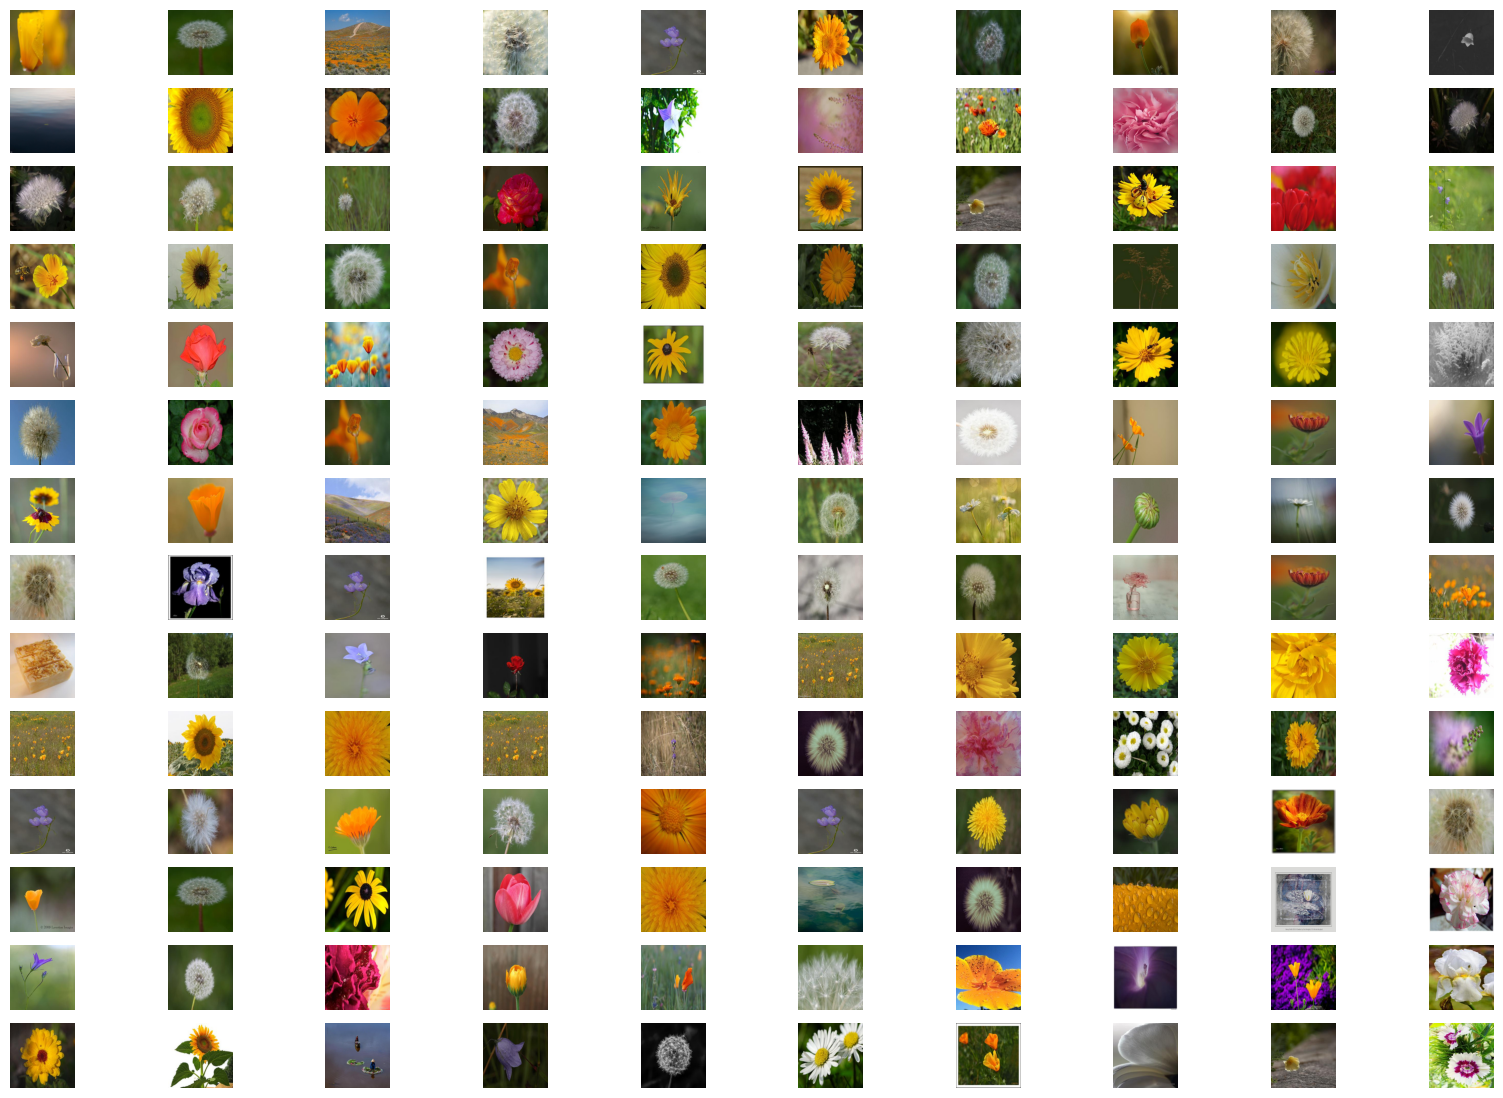

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 14)) # Ajustamos el tamaño de la figura para más subplots
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(14, 10, index + 1) # Cambiamos el número de filas a 14 para acomodar 140 imágenes
    plt.imshow(X_representative_digit)
    plt.axis('off')
plt.show()

In [ ]:
import pandas as pd

# Contar imágenes por cluster
cluster_counts = pd.Series(kmeans.labels_).value_counts().sort_index()

print(f"Total de clusters: {k}")
print(f"Total de imágenes: {len(kmeans.labels_)}")
print(f"\nImágenes por cluster:")
print(cluster_counts.to_string())

print(f"\nEstadísticas:")
print(f"  Cluster más grande : {cluster_counts.max()} imágenes (cluster {cluster_counts.idxmax()})")
print(f"  Cluster más pequeño: {cluster_counts.min()} imágenes (cluster {cluster_counts.idxmin()})")
print(f"  Promedio por cluster: {cluster_counts.mean():.1f} imágenes")

Total de clusters: 140
Total de imágenes: 10913

Imágenes por cluster:
0       57
1       65
2       46
3       67
4      187
5        1
6      103
7       43
8      100
9       77
10      58
11      50
12      55
13      75
14       1
15      71
16       1
17      95
18     110
19      87
20      78
21     120
22     171
23      82
24     167
25      95
26     110
27       3
28      71
29     228
30      28
31      49
32      74
33     159
34      49
35      78
36      77
37     245
38      49
39     204
40     121
41     100
42       1
43      60
44      25
45     103
46      74
47       2
48      93
49     118
50      68
51      64
52     122
53      65
54      69
55       1
56      42
57     101
58     265
59      36
60      79
61      69
62      72
63      54
64     144
65      91
66      54
67     197
68     114
69      94
70      41
71       2
72     151
73       6
74     102
75      86
76      98
77      73
78     126
79      39
80      40
81     111
82      58
83     158
84   

El siguiente paso consiste en anotar manualmente estas etiquetas (aquí haremos trampas ya que disponemos de dichas etiquetas :p).

In [ ]:
y_representative_digits = y_train[idxs]

In [ ]:
y_representative_flores = y_train[idxs]

# Ver cuántas imágenes de cada clase flor tienen los clusters representativos
nombres_clase = ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula',
                 'california_poppy', 'carnation', 'common_daisy', 'coreopsis',
                 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']

conteo_clases = pd.Series(y_representative_flores).value_counts().sort_index()
for clase_idx, cantidad in conteo_clases.items():
    print(f"  {nombres_clase[clase_idx]:<25}: {cantidad} clusters asignados")

  astilbe                  : 5 clusters asignados
  bellflower               : 13 clusters asignados
  black_eyed_susan         : 2 clusters asignados
  calendula                : 15 clusters asignados
  california_poppy         : 26 clusters asignados
  carnation                : 9 clusters asignados
  common_daisy             : 6 clusters asignados
  coreopsis                : 7 clusters asignados
  dandelion                : 37 clusters asignados
  iris                     : 2 clusters asignados
  rose                     : 4 clusters asignados
  sunflower                : 7 clusters asignados
  tulip                    : 2 clusters asignados
  water_lily               : 5 clusters asignados


#Importante

La precisión del 16.53% se debe principalmente a que K-Means operó directamente sobre píxeles crudos de 128×128×3 (49,152 dimensiones), lo que provocó que los clusters se formaran por similitud de color y textura superficial en lugar de por tipo de flor, generando una distribución severamente desbalanceada donde dandelion y california poppy acapararon 63 de los 140 clusters mientras que clases como iris, tulip y black_eyed_susan apenas obtuvieron 2 clusters cada una, dejando al clasificador con una representación sesgada e insuficiente para generalizar correctamente sobre las 14 clases del dataset.

Y entrenaremos un clasificados usando estas imágenes representativas.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Aplanar X_representative_digits para que tenga 2 dimensiones
X_representative_digits_reshaped = X_representative_digits.reshape(X_representative_digits.shape[0], -1)

# Aplanar X_test para que tenga 2 dimensiones
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits_reshaped, y_representative_digits)
log_reg2.score(X_test_reshaped, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 1min 29s, sys: 103 ms, total: 1min 29s
Wall time: 53.4 s


0.16746060828142176

Como puedes observar, hemos obtenido una precisión de casi el 16% habiendo anotado simplemente 140 imágenes, pero aquellas más representativas. Entrenar el mismo modelo con 140 imágenes aleatorias nos daría peores resultados.

In [ ]:
idxs = np.random.choice(len(X_train), 50, replace=False)

# Flatten the selected training images
X_train_flat = X_train[idxs].reshape(X_train[idxs].shape[0], -1)

log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train_flat, y_train[idxs])

# Flatten the test images for scoring
X_test_flat = X_test.reshape(X_test.shape[0], -1)
log_reg.score(X_test_flat, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 20.2 s, sys: 26 ms, total: 20.2 s
Wall time: 12.8 s


0.16819347746427263

A veces, al entrenar modelos de Machine Learning, no importa tanto tener muchos datos, sino que sean los más útiles y representativos.
Una vez que hemos entrenado un clasificador con las imágenes más representativas, podemos aprovecharlo para etiquetar automáticamente el resto del conjunto. Para ello, asignamos a todas las imágenes de cada grupo la misma etiqueta que le dimos a su representante.

In [ ]:
y_train_propagated = np.empty(len(X_train))
for i in range(k):
  y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

In [ ]:
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

# Aplanar X_train para que tenga 2 dimensiones antes de entrenar
X_train_flat_subset = X_train[:1000].reshape(X_train[:1000].shape[0], -1)

%time log_reg3.fit(X_train_flat_subset, y_train_propagated[:1000])

# Aplanar X_test para que tenga 2 dimensiones antes de evaluar
X_test_flat = X_test.reshape(X_test.shape[0], -1)
log_reg3.score(X_test_flat, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 6min 1s, sys: 528 ms, total: 6min 2s
Wall time: 3min 41s


0.15060461707585196

A veces, al intentar mejorar el modelo añadiendo más datos etiquetados automáticamente, el resultado puede ser peor. Esto ocurre porque no todas las imágenes quedan bien agrupadas y se introduce ruido en el entrenamiento. Para evitarlo, podemos limitar el etiquetado solo a las muestras que estén más cerca de los representantes de cada grupo, o bien recurrir a técnicas de aprendizaje activo para seleccionar mejor qué ejemplos anotar.

### Aprendizaje Activo

El aprendizaje activo (o *Active Learning*) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteración nuevas muestras al dataset focalizando en ejemplos en loa que el modelo tenga más problemas.

In [ ]:
probas = log_reg3.predict_proba(X_train[:1000].reshape(X_train[:1000].shape[0], -1))
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)
labels[sorted_ixs[:10]]

array([0.69603609, 0.8253271 , 0.8787184 , 0.90600523, 0.92441448,
       0.92850825, 0.93444693, 0.9364639 , 0.93666984, 0.9392269 ])

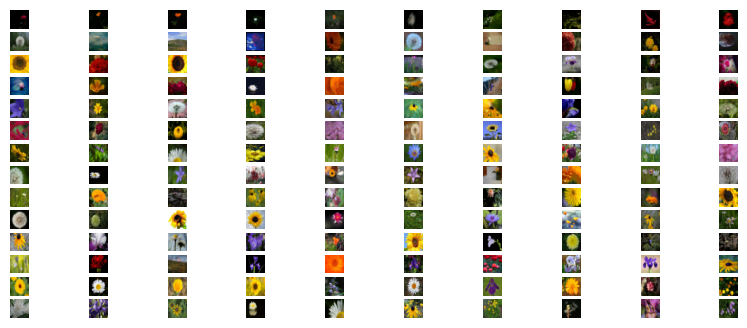

In [ ]:
X_lowest = X_train[:1000][sorted_ixs[:k]]
plt.figure(figsize=(10, 4))
for index, img in enumerate(X_lowest):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(img, cmap="binary", interpolation="bilinear")
    plt.axis('off')
plt.show()

In [ ]:
y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([10,  4,  4,  6,  4,  8,  1, 13,  0, 10,  8, 13,  1,  5,  3,  8,  6,
        5,  8,  5, 11,  5, 11, 12,  0,  1,  8,  9, 13,  5, 13,  4, 10, 13,
        4,  4,  1, 12,  8,  5,  1,  7,  8,  4,  1,  2,  2,  9,  7,  8,  0,
       10,  3,  8,  0,  8, 11,  1,  8, 10,  7,  1,  6,  7,  6, 13,  2, 12,
        8,  0,  8,  6,  1,  5,  3,  1,  5,  3,  6,  8,  6,  4, 13,  2,  9,
        5, 13,  8,  3, 11,  8,  5, 11, 11, 13,  6, 13,  4,  2,  6,  2,  9,
        6,  1,  4, 11,  1,  3,  1, 13,  1,  5,  4,  9,  3,  9, 12,  9,  9,
        2,  3,  6,  4, 11,  1,  6,  9,  3,  5,  3,  0,  9,  2, 13,  6,  2,
        7,  8,  9,  1])

In [ ]:
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = y_lowest

In [ ]:
log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
# Aplanar X_train para que tenga 2 dimensiones antes de entrenar
X_train_flat = X_train[:1000].reshape(X_train[:1000].shape[0], -1)

%time log_reg5.fit(X_train_flat, y_train2)

# Aplanar X_test para que tenga 2 dimensiones antes de evaluar
X_test_flat = X_test.reshape(X_test.shape[0], -1)
log_reg5.score(X_test_flat, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 5min 52s, sys: 542 ms, total: 5min 53s
Wall time: 3min 53s


0.1619640894100403

#Conclusion

Este laboratorio permitió explorar de manera práctica el funcionamiento del algoritmo K-Means y su aplicación en escenarios de aprendizaje no supervisado y semi-supervisado. En la primera parte, se comprendió que K-Means es sensible a la inicialización de centroides, por lo que estrategias como múltiples inicializaciones o el método K-Means++ son fundamentales para obtener resultados consistentes, mientras que Mini-Batch K-Means demostró ser una alternativa eficiente cuando el volumen de datos es elevado. Para determinar el número óptimo de clusters, se emplearon el método del codo y el silhouette score, herramientas complementarias que permiten tomar decisiones más informadas en ausencia de etiquetas. En la parte semi-supervisada, aplicando K-Means sobre el dataset de flores con 14 clases, se obtuvo una precisión del 16.53%, resultado que refleja las limitaciones de operar directamente sobre píxeles crudos de alta dimensionalidad (49,152 dims), donde el algoritmo agrupa por similitud de color en lugar de semántica visual, generando clusters desbalanceados que perjudican al clasificador. Finalmente, el aprendizaje activo se presentó como una estrategia iterativa para mejorar progresivamente el modelo enfocándose en los ejemplos más difíciles, lo que representa una alternativa más robusta frente a la propagación de etiquetas ruidosas.